# Logistic Regression
Logistic regression is a foundational algorithm for `binary classification` tasks. Unlike linear regression, which predicts continuous values, logistic regression predicts the probability that something belongs to one of two classes. It transforms these probabilities into clean 0 or 1 predictions, making it perfect for yes/no, pass/fail, or true/false scenarios.

Why is it so popular? Because it's stable, fast, and highly interpretable.

## Logistic Regression Pipeline
1. Input Features: Start with input features (X1, X2, ..., Xn) that describe the data points.
2. Linear Combination: Compute a weighted sum of these features using weights (W1, W2, ..., Wn) and a bias term (b):
   Z = W1*X1 + W2*X2 + ... + Wn*Xn + b
3. Sigmoid Function: Apply the sigmoid function to Z to convert it into a probability (P) between 0 and 1:
   P = 1 / (1 + e^(-Z))
4. Probability Interpretation: The output P represents the probability of belonging to the positive class (class 1). A value close to 1 indicates high confidence in class 1, while a value close to 0 indicates high confidence in class 0.
5. Decision Threshold: Set a threshold (commonly 0.5) to classify the data point:
   - If P >= 0.5, classify as class 1
   - If P < 0.5, classify as class 0

## Sigmoid Function

The sigmoid formula transforms any input z into a smooth S-curve that transitions gracefully from 0 to 1, providing interpretable probabilities for any input value.

Formula:
```math 
\sigma(z) = \frac{1}{1 + e^{-z}}
```

Where:
z = Linear predictor (weighted sum of inputs) negative infinity < z < infinity

1. Negative z Values: As z approaches negative infinity, the sigmoid output approaches 0. This indicates a very low probability of belonging to the positive class.
2. Positive z Values: As z approaches positive infinity, the sigmoid output approaches 1. This indicates a very high probability of belonging to the positive class.
3. z = 0: When z is exactly 0, the sigmoid output is 0.5, representing an equal probability of belonging to either class.

#### Why sigmoid is essential?
- Meaningful Probabilities: It converts linear outputs into probabilities, making it easier to interpret results.
- Smooth Classification: The smooth curve allows for gradual transitions between classes, which is useful for decision-making.
- Optimization Friendly: The mathematical properties of the sigmoid function facilitate efficient optimization during model training.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1/(1+ np.exp(-z))

z_values = np.linspace(-8, 8, 50)
sig_values = sigmoid(z_values)

threshold = 0.5     # The prediction will change at this threshold
predictions = (sig_values >= threshold).astype(int)

pred_df = pd.DataFrame({
    "z": z_values,
    "sigmoid(z)": np.round(sig_values, 4),
    "prediction": predictions
})

pred_df

,z,sigmoid(z),prediction
0,-8.000000,0.0003,0
1,-7.673469,0.0005,0
2,-7.346939,0.0006,0
3,-7.020408,0.0009,0
4,-6.693878,0.0012,0
5,-6.367347,0.0017,0
6,-6.040816,0.0024,0
7,-5.714286,0.0033,0
8,-5.387755,0.0046,0
9,-5.061224,0.0063,0


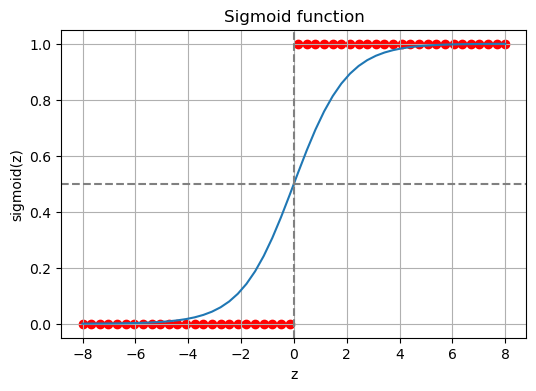

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(z_values, sig_values)
plt.scatter(z_values, predictions, color="red")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid function")
plt.grid(True)
plt.axhline(0.5, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.show()

### Odds and Log-Odds
In logistic regression, the output of the sigmoid function can be interpreted in terms of odds and log-odds.
- Odds: The odds of an event occurring is the ratio of the probability of the event happening to the probability of it not happening. If P is the probability of the positive class, then the odds are given by:
  ```math
  \text{Odds} = \frac{P}{1 - P}
  ```
Example: If P = 0.8, then the odds are 0.8 / (1 - 0.8) = 4. This means the event is 4 times more likely to occur than not occur. If P = 0.2, then the odds are 0.2 / (1 - 0.2) = 0.25, meaning the event is 4 times less likely to occur than not occur. If P = 0.5, the odds are 1, indicating equal likelihood of occurrence and non-occurrence.
- Log-Odds: The log-odds (or logit) is the natural logarithm of the odds. It transforms the odds into a continuous scale that can take any real value:
  ```math
  \text{Log-Odds} = \log\left(\frac{P}{1 - P}\right) = w^TX + b
  ```
Where w^TX + b is the linear combination of input features and weights and left side is the transformation probability to log-odds scale.\
Example: If the odds are 4, the log-odds are log(4) ≈ 1.386. If the odds are 0.25, the log-odds are log(0.25) ≈ -1.386. If the odds are 1, the log-odds are log(1) = 0.

##### Why Choose Log-Odds?
- Unbounded Scale: Log-odds can take any real value(negative infinity to positive infinity), making them suitable for linear modeling.
- Linear Relationship: The log-odds have a linear relationship with the input features, which simplifies the modeling process.

### Decision Boundary
In logistic regression, the decision boundary is the threshold that separates the two classes based on the predicted probabilities. If the odds are 1, the log-odds are log(1) = 0 at this point w^TX + b = 0 -> Decision Boundary.\
Example: Let w=2 and b=-6\
then, 0 = 2*X - 6 -> X = 3\
So, when X=3, the model is equally likely to predict either class(p=0.5). Values of X greater than 3 will lead to predictions of class 1, while values less than 3 will lead to predictions of class 0.


## Binary Cross-Entropy Loss(Log Loss)
Binary Cross-Entropy Loss, also known as Log Loss, is a widely used loss function for binary classification tasks in machine learning. It measures the performance of a classification model whose output is a probability value between 0 and 1. The goal of using this loss function is to minimize the difference between the predicted probabilities and the actual class labels (0 or 1).

Cost Function Formula:
```math
J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
```
Where:
- J(w,b): The cost function that we want to minimize.
- m: The number of training examples.
- yi: The actual class label for the i-th training example (0 or 1).
- pi: The predicted probability of the positive class (class 1) for the i-th training example, obtained from the sigmoid function.

## Gradient Descent Variables
Gradient Descent is an optimization algorithm used to minimize the cost function by iteratively updating the model parameters (weights and bias) in the direction of the steepest descent of the cost function. Gradient descent always moves the opposite direction of the gradient to find the minimum.

- Learning Rate (α): A hyperparameter that controls the step size during the optimization process. A smaller learning rate may lead to slower convergence, while a larger learning rate may cause overshooting.
- Weights (w): The parameters of the model that are adjusted during training to minimize the loss function.
- Bias (b): An additional parameter that allows the model to fit the data better by providing an offset.

Gradient Descent Update Rules:
```math
w = w - \alpha \frac{\partial J(w,b)}{\partial w}\\
b = b - \alpha \frac{\partial J(w,b)}{\partial b}
```
Where Gradients:
```math
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (p_i - y_i) X_i\\
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (p_i - y_i)
```
Where:
- ∂J(w,b)/∂w: The gradient of the cost function with respect to the weights.
- ∂J(w,b)/∂b: The gradient of the cost function with respect to the bias.
- Xi: The input feature for the i-th training example.
- yi: The actual class label for the i-th training example (0 or 1).

If the probability is high from the actual the gradient will be positive and the weight & bias will decrease. If the probability is low from the actual the gradient will be negative and the weight & bias will increase. This way the model learns to adjust weights and bias to minimize the loss function over time.

Example of Decision Boundary Calculation:
Let w=0.8 and b=-3, a student studies for 5 hours(X=5)
- Compute z: z= w*X + b = 0.8*5 - 3 = 1
- Apply Sigmoid: p = sigmoid(z) = 1/(1+e^(-1)) ≈ 0.731
- Class Prediction: Since p > 0.5, predict class 1 (pass)
- Decision Boundary: The decision boundary occurs when z=0, so 0 = w*X + b -> X = -b/w = -3/0.8 = 3.75 hours. If the student studies more than 3.75 hours, they are predicted to pass; otherwise, they are predicted to fail.

Example of Gradient Descent Update:
Let w=0.5 and b=-1 with a learning rate α=0.1, and a training example (X1=2, y1=1)
- Compute linear score: z = w*X1 + b = 0.5*2 - 1 = 0
- Apply Sigmoid: p1 = sigmoid(z) = 1/(1+e^(0)) = 0.5
- Compute Gradients:
  - ∂J/∂w = (p1 - y1) * X1 = (0.5 - 1) * 2 = -1
  - ∂J/∂b = (p1 - y1) = (0.5 - 1) = -0.5
- Update Weights and Bias:
  - w = w - α * ∂J/∂w = 0.5 - 0.1 * (-1) = 0.6
  - b = b - α * ∂J/∂b = -1 - 0.1 * (-0.5) = -0.95
- New linear score after update: z_new = w*X1 + b = 0.6*2 - 0.95 = 0.25
- New predicted probability: p1_new = sigmoid(z_new) = 1/(1+e^(-0.25)) ≈ 0.562
- So after one update, the predicted probability for the training example has increased from 0.5 to approximately 0.562, indicating that the model is learning to predict the positive class more confidently.

In [21]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_full = data.data
y_full = data.target
feature_names = data.feature_names
df = pd.DataFrame(X_full, columns=feature_names)
df["target"] = y_full

df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [23]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)       # stratify to maintain class distribution ,means in both train and test set the ratio of classes will be same as original data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=100)
clf.fit(X_train_scaled, y_train)

y_test_pred = clf.predict(X_test_scaled)
y_test_proba = clf.predict_proba(X_test_scaled)[:, 1]

y_test_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

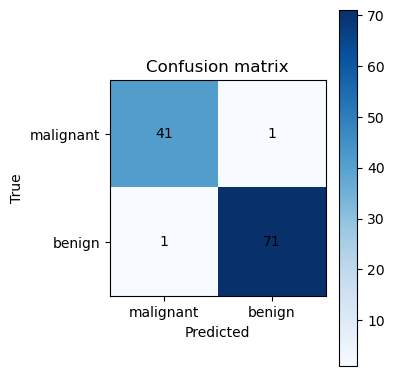

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")        #display data as an image/matrix
plt.title("Confusion matrix")
plt.colorbar()
tick_labels = data.target_names
plt.xticks([0, 1], tick_labels)
plt.yticks([0, 1], tick_labels)
plt.xlabel("Predicted")
plt.ylabel("True")

# Add numbers to each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [26]:

from sklearn.metrics import classification_report

print("\nClassification repot:\n", classification_report(y_test, y_test_pred))


Classification repot:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### Classification Report

A classification report is a quick scorecard that tells how well the classification model performed.
It gives four important numbers for each class:

1. Precision: Out of everything the model predicted as this class, how many were actually correct. Think of it like: *When the model says “yes,” how often is it not lying?*

2. Recall: Out of all the real items in this class, how many did the model successfully find. Think of it like: *How many real positives did the model manage to catch?*

3. F1 Score: The balanced score between precision and recall. If precision is good but recall is horrible, F1 exposes it.
If precision is good but recall is horrible, F1 exposes it.

4. Support: How many actual samples are in each class.  This helps to check if the dataset is imbalanced.

5. Accuracy: The overall accuracy of the model across all classes.

6. Macro Average: The unweighted average of precision, recall, and F1 score across all classes. It treats all classes equally, regardless of their support.

7. Weighted Average: The average of precision, recall, and F1 score across all classes, weighted by the number of samples in each class (support). This gives more importance to classes with more samples.

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 score:", f1)

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 score: 0.9861111111111112


In [29]:
# Try different thresholds and see how precision and recall change
thresholds = np.linspace(0.1, 0.9, 9)#0.1,0.2,0.3,0.4...
rows = []

for thr in thresholds:
    y_thr_pred = (y_test_proba >= thr).astype(int)
    acc_thr = accuracy_score(y_test, y_thr_pred)
    prec_thr = precision_score(y_test, y_thr_pred)
    rec_thr = recall_score(y_test, y_thr_pred)
    f1_thr = f1_score(y_test, y_thr_pred)
    rows.append([thr, acc_thr, prec_thr, rec_thr, f1_thr])

thr_df = pd.DataFrame(rows, columns=["threshold", "accuracy", "precision", "recall", "f1"])
thr_df

,threshold,accuracy,precision,recall,f1
0,0.1,0.956140,0.935065,1.000000,0.966443
1,0.2,0.982456,0.972973,1.000000,0.986301
2,0.3,0.982456,0.972973,1.000000,0.986301
3,0.4,0.982456,0.986111,0.986111,0.986111
4,0.5,0.982456,0.986111,0.986111,0.986111
5,0.6,0.956140,0.985507,0.944444,0.964539
6,0.7,0.947368,0.985294,0.930556,0.957143
7,0.8,0.938596,0.985075,0.916667,0.949640
8,0.9,0.894737,0.983871,0.847222,0.910448


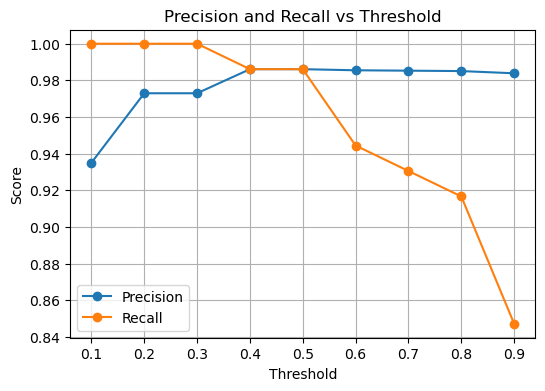

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

Threshold trade-offs:
- Increasing threshold may decrease accuracy but increase precision.
- Decreasing threshold may increase accuracy but decrease precision.
- Precision vs Recall: Increasing precision may decrease recall, and vice versa. The F1 score helps balance this trade-off.

## L2 Regularization (Ridge Regression)
L2 regularization, also known as Ridge Regression, is a technique used to prevent overfitting in machine learning models, particularly in linear and logistic regression. It works by adding a penalty term to the loss function that discourages large coefficients in the model.

How it works:
1. Adds a penalty term based on the square of the magnitude of coefficients
2. Shrinks weights smoothly towards zero
3. Improves generalization

### The C peramter
In scikit-learn's LogisticRegression, the C parameter controls regularization strength. Think of it as a volume knob that adjusts how much penalty is applied.
- Small C values (e.g., 0.01) mean strong regularization(more penalty), leading to smaller coefficients and a simpler model.
- Large C values (e.g., 100) mean weak regularization(less penalty), allowing larger coefficients and a more complex model.

Finding the right C value requires experimentation, typically through cross-validation to balance simplicity and performance.

#### What Regularization Fixes
1. Prevents Coefficient Explosion: Large coefficients can lead to overfitting. L2 regularization keeps them in check.
2. Reduces Overfitting: By penalizing large weights, the model focuses on the most important features, improving its ability to generalize to new data.
3. Smoother Boundaries: In classification tasks, L2 regularization helps create smoother decision boundaries, reducing sensitivity to noise in the training data.
4. Stabilizes Performance: Regularized models tend to have more stable performance across different datasets, as they are less likely to fit to random fluctuations in the training data.

The L2 regularization term is the sum of the squares of the coefficients multiplied by a regularization parameter (λ):
```math
\text{L2 Penalty} = \lambda \sum_{j=1}^{n} w_j^2
```

Where:
- λ (lambda): Regularization parameter that controls the strength of the penalty. A higher λ means more regularization.
- wj: Coefficients of the model.

The overall loss function with L2 regularization becomes:
```math
J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] + \lambda \sum_{j=1}^{n} w_j^2
```

In [31]:
# Two models with different regularization strengths
clf_weak_reg = LogisticRegression(max_iter=100, C=1000.0) #Weak regularixation
clf_strong_reg = LogisticRegression(max_iter=100, C=0.01) #Strong regularixation

clf_weak_reg.fit(X_train_scaled,y_train)
clf_strong_reg.fit(X_train_scaled,y_train)

y_pred_weak = clf_weak_reg.predict(X_test_scaled)
y_pred_strong = clf_strong_reg.predict(X_test_scaled)

print("Weak reg (C=1000) test accuracy: ", accuracy_score(y_test, y_pred_weak))
print("Strong reg (C=0.01) test accuracy: ", accuracy_score(y_test, y_pred_strong))

Weak reg (C=1000) test accuracy:  0.9298245614035088
Strong reg (C=0.01) test accuracy:  0.9473684210526315


In [33]:
# Compare coefficient magnitudes
coef_weak = clf_weak_reg.coef_[0]
coef_strong = clf_strong_reg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef_weak_C_1000":np.round(coef_weak, 4),
    "coef_strong_C_0.01":np.round(coef_strong, 4)
})

coef_df.head(15)

,feature,coef_weak_C_1000,coef_strong_C_0.01
0,mean radius,6.9630,-0.2123
1,mean texture,-7.0531,-0.1806
2,mean perimeter,3.2030,-0.2100
3,mean area,-3.0704,-0.1963
4,mean smoothness,-5.2702,-0.1024
5,mean compactness,30.1389,-0.0984
6,mean concavity,-9.9793,-0.1498
7,mean concave points,-6.6217,-0.2069
8,mean symmetry,0.2938,-0.0809
9,mean fractal dimension,-7.4355,0.0797


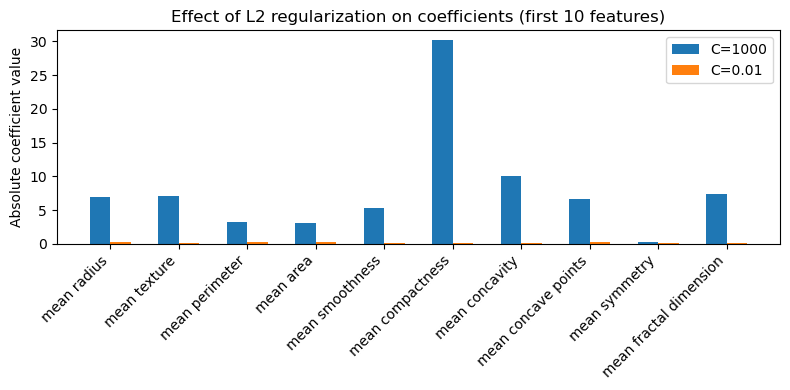

In [36]:
n_plot = 10
indices = np.arange(n_plot)        # array([0, 1, 2, ..., n_plot-1])# What's the purposr of indices here? Index is used to position the bars on the x-axis for the first n_plot features.

plt.figure(figsize=(8, 4))
plt.bar(indices - 0.15, np.abs(coef_weak[:n_plot]), width=0.3, label="C=1000")
plt.bar(indices + 0.15, np.abs(coef_strong[:n_plot]), width=0.3, label="C=0.01")
plt.xticks(indices, feature_names[:n_plot], rotation=45, ha="right")
plt.ylabel("Absolute coefficient value")
plt.title("Effect of L2 regularization on coefficients (first 10 features)")
plt.legend()
plt.tight_layout()
plt.show()